In [ ]:
import kagglehub
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
import os
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/weather-type-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-type-classification' dataset.
Path to dataset files: /kaggle/input/weather-type-classification


In [ ]:
csv_path = os.path.join(path, "weather_classification_data.csv")

df = pd.read_csv(csv_path)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [ ]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


In [ ]:
X = df.drop("Weather Type", axis=1)
y = df['Weather Type']

le = LabelEncoder()
y = le.fit_transform(y)

categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Splitting prior to scaling to strictly prevent data leakage from the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numerical_cols = ["Temperature", "Humidity", "Wind Speed", "Precipitation (%)", "Atmospheric Pressure", "UV Index", "Visibility (km)"]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train = torch.tensor(X_train.astype(float).values, dtype=torch.float32)
X_test  = torch.tensor(X_test.astype(float).values, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Train dataset:", len(train_dataset))
print("Test dataset:", len(test_dataset))

X_batch, y_batch = next(iter(train_loader))
print(f"Training batch input shape: {X_batch.shape}")
print(f"Training batch labels shape: {y_batch.shape}")

Using device: cpu
Train dataset: 10560
Test dataset: 2640
Training batch input shape: torch.Size([32, 15])
Training batch labels shape: torch.Size([32])


In [ ]:
class NN4Layer(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NN4Layer, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.layer4 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        a1 = self.relu(self.layer1(x))
        a2 = self.relu(self.layer2(a1))
        a3 = self.relu(self.layer3(a2))
        # Returns raw logits; activation is handled by the loss function (CrossEntropyLoss)
        output = self.layer4(a3)
        return output

In [ ]:
def train_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(train_loader)

In [ ]:
def validate(model, criterion, test_loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()

            probabilities = F.softmax(outputs, dim=1)
            predicted = torch.argmax(probabilities, dim=1)

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    return running_loss / len(test_loader), correct / total

In [ ]:
input_dim = X_train.shape[1]
hidden_dim = 14
output_dim = 4

model = NN4Layer(input_dim, hidden_dim, output_dim).to(device)

print("Model Architecture:\n")
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params}")

Model Architecture:

NN4Layer(
  (layer1): Linear(in_features=15, out_features=14, bias=True)
  (layer2): Linear(in_features=14, out_features=14, bias=True)
  (layer3): Linear(in_features=14, out_features=14, bias=True)
  (layer4): Linear(in_features=14, out_features=4, bias=True)
  (relu): ReLU()
)

Total trainable parameters: 704


In [ ]:
num_epochs = 20
learning_rate = 0.001

# CrossEntropyLoss expects raw logits as input
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=learning_rate)

In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

print('Starting Training...')
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
    val_loss, val_accuracy = validate(model, criterion, test_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

print('Training Complete!')

Starting Training...
Epoch [1/20], Train Loss: 0.8949, Val Loss: 0.4877, Val Accuracy: 0.8606
Epoch [2/20], Train Loss: 0.4005, Val Loss: 0.3753, Val Accuracy: 0.8735
Epoch [3/20], Train Loss: 0.3316, Val Loss: 0.3226, Val Accuracy: 0.8841
Epoch [4/20], Train Loss: 0.2944, Val Loss: 0.2936, Val Accuracy: 0.8936
Epoch [5/20], Train Loss: 0.2695, Val Loss: 0.2725, Val Accuracy: 0.8936
Epoch [6/20], Train Loss: 0.2537, Val Loss: 0.2597, Val Accuracy: 0.8970
Epoch [7/20], Train Loss: 0.2401, Val Loss: 0.2510, Val Accuracy: 0.9027
Epoch [8/20], Train Loss: 0.2311, Val Loss: 0.2390, Val Accuracy: 0.9019
Epoch [9/20], Train Loss: 0.2229, Val Loss: 0.2316, Val Accuracy: 0.9053
Epoch [10/20], Train Loss: 0.2173, Val Loss: 0.2284, Val Accuracy: 0.9045
Epoch [11/20], Train Loss: 0.2132, Val Loss: 0.2268, Val Accuracy: 0.9076
Epoch [12/20], Train Loss: 0.2091, Val Loss: 0.2192, Val Accuracy: 0.9068
Epoch [13/20], Train Loss: 0.2070, Val Loss: 0.2138, Val Accuracy: 0.9076
Epoch [14/20], Train Loss:

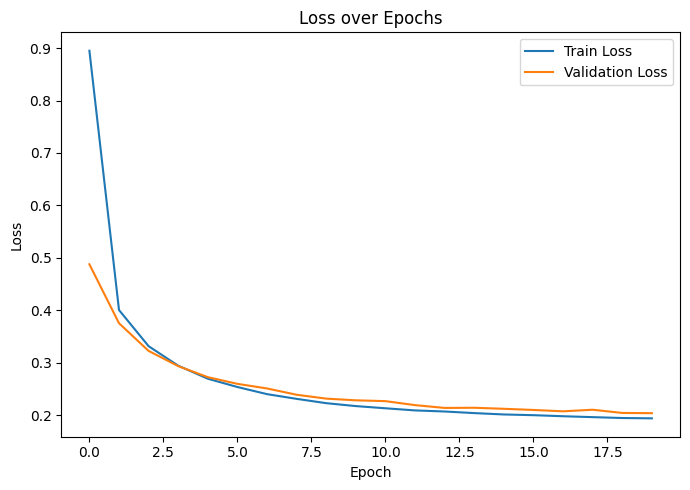

In [ ]:
# Plotting results
plt.figure(figsize=(7, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model parameters
torch.save(model.state_dict(), "weather_nn4layer.pth")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Recreate the model architecture
model = NN4Layer(input_dim, hidden_dim, output_dim)
# Load saved parameters
model.load_state_dict(torch.load("weather_nn4layer.pth"))
# Set model to evaluation mode
model.eval()
print("Model loaded successfully!")

Model loaded successfully!
